 **Before you start:** Please read the ***Submission*** section at the bottom of the notebook carefully.

# Explanatory questions
Answer the following questions with the help of the material learned in the classroom and the introduced book:



1. What is a test set, and why whould you want to use it?

Answer: A test set is a set of data that is used to test the performance of a trained model. It is used to evaluate the performance of the model on unseen data. It is used to check for overfitting and underfitting of the model.

2. What is the porpuse of a validation test?

Answer: A validation test is used to tune the hyperparameters of the model. It is used to find the best hyperparameters for the model.

3. What can go wrong if you tune hyperparameters using the test set?

Answer: If we tune the hyperparameters using the test set, the model will be overfitting the test set. The model will not be able to perform well on unseen data.


In [ ]:
# remove all files in the directory for colaboratory
!rm -r sample_data
# unzip data.zip and replace all without prompt
!unzip -o data.zip
# remove unnecessary files
!rm -r data.zip Linear_and_Logistic_Regression.ipynb
# see what's in the directory
!ls

rm: cannot remove 'sample_data': No such file or directory
unzip:  cannot find or open data.zip, data.zip.zip or data.zip.ZIP.
rm: cannot remove 'data.zip': No such file or directory
rm: cannot remove 'Linear_and_Logistic_Regression.ipynb': No such file or directory
images	insurance.csv  insurance.html


# Machine Learning's "Hello World"!

This is the assignment **#1** of the **Machine Learning** graduate course at **Shahid Beheshti University - Fall 2023**

In this notebook, we explore the basic and traditional machine learning algorithms and see how to implement predictive models powered by [Sickit-Learn](https://scikit-learn.org/stable/) library.




In [ ]:
# lets import the essential packages we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Medical Insurance Cost Prediction

Many factors that affect how much you pay for health insurance are not within your control. Nonetheless, it's good to have an understanding of what they are. Here are some factors that affect how much health insurance premiums cost:

- **age**: age of primary beneficiary
- **sex**: insurance contractor gender, female, male
- **bmi**: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight using the ratio of height to weight, ideally 18.5 to 24.9
- **smoker**: Smoking
- **children**: Number of children covered by health insurance / Number of dependents

In [ ]:
# fix, the data is in the wrong directory
# datasets/insurance.csv => insurance.csv
df = pd.read_csv('insurance.csv')
print("Shape of the dataset: {}".format(df.shape))
df.head(5)

Shape of the dataset: (1338, 6)


,age,sex,bmi,children,smoker,charges
0,45,female,27.83,2,no,8515.7587
1,24,male,32.70,0,yes,34472.8410
2,34,female,29.26,3,no,6184.2994
3,64,male,34.50,0,no,13822.8030
4,27,female,24.10,0,no,2974.1260


There is a library named `pandas_profiling` in Python include a method named as `ProfileReport()` which generate a basic report on the input DataFrame. The report consist of the following:

- DataFrame overview,
- Each attribute on which DataFrame is defined,
- Correlations between attributes (Pearson Correlation and Spearman Correlation), and
- A sample of DataFrame.

By running the cell below, a HTML file will be created next to the notebook in the project directory.

In [ ]:
!pip install pandas-profiling==3.5

In [ ]:
# import pandas_profiling library
# fix: package name was changed from ydata-profiling to pandas-profiling
import pandas_profiling

# forming ProfileReport and save
# as a HTML file
html = pandas_profiling.ProfileReport(df)
html.to_file('insurance.html')

# show the report inline
from IPython.display import HTML

HTML(filename='insurance.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/multimethod/__init__.py:315: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  return func(*args, **kwargs)


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Number of variables,6
Number of observations,1338
Missing cells,0
Missing cells (%),0.0%
Duplicate rows,1
Duplicate rows (%),0.1%
Total size in memory,62.8 KiB
Average record size in memory,48.1 B
Numeric,4
Categorical,1
Boolean,1


## 1.1 Linear Regression

**Linear Regression** is a machine learning algorithm based on **supervised learning**. It performs a regression task. Regression models a target prediction value based on independent variables. It is mostly used for finding out the relationship between variables and forecasting.

<img src="images/linear-regression.png" width=400 height=400 />

In this problem, we want to create a linear regression model for the existing dataest. For simplicity, we only consider one of the features of the data `bmi` and the target `charges`. Also we are just interested in the people who smokes. So:

Text(0, 0.5, 'charges')

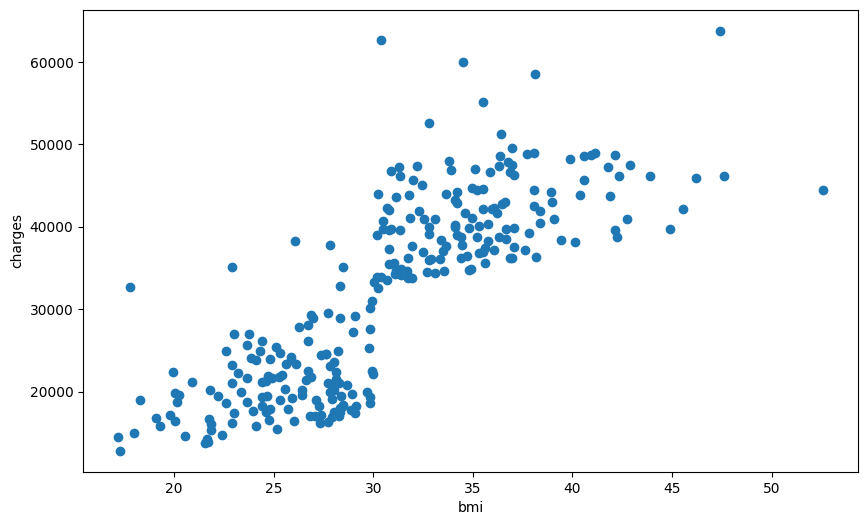

In [ ]:
X = df[df['smoker'] =='yes']['bmi'].values  # X now is a numpy array
target = df[df['smoker'] =='yes']['charges'].values  # also target is a numpy array

# plot the points
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = X, y = target)
plt.xlabel("bmi")
plt.ylabel("charges")

## Q1. Implement `SimpleLinearRegression` class. (20 points)

Fill the blank lines with the least possible codes. Note that redundant codes may lead to reduce your score.

**Note**: Do not add any other functions to the class defined below.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


class SimpleLinearRegression():
    def __init__(self):
        self.intercept = 0.0
        self.coeff = 0.0

    def train(self, X_train, y_train):
        # TODO: Thin function takes X_train: numpy.ndarray and y : numpy.ndarray
        # and fit a linear line to the points with the least loss
        # Use sklearn.linear_model.LinearRegression for this purpose
        # At last this function must set the intercept and coefficient of the predicted line

        intercept = 0.0
        coeff = 0.0

        ############# My code here ############
        # reshape the data to fit the model
        x_train = X_train.reshape(-1, 1)

        print(X_train.shape)
        print(x_train.shape)
        print(y_train.shape)

        # create a linear regression object
        model = LinearRegression()

        # train the model using the training sets
        model.fit(x_train, y_train)

        # save the model for later use
        self.train_model = model

        # get the intercept and coefficient
        intercept = model.intercept_
        coeff = model.coef_

        #########################################

        self.intercept = intercept
        self.coeff = coeff

        return coeff, intercept

    def compute_loss(self, y_pred, y_true, loss_fn = 'MSE'):
        # TODO: Implement this function that takes y_pred and y_true
        # as a 1-dimensional numpy array (n_samples,) and returns
        # the loss using sklearn.metrics functions

        possible_loss_functions = ['MSE', 'MAE', 'R2_Score']

        loss = None
        if loss_fn == 'MSE':
            ############# My code here ############
            # this is the mean squared error
            loss = metrics.mean_squared_error(y_true, y_pred)
            #########################################
        elif loss_fn == 'MAE':
            ############# My code here ############
            # this is the mean absolute error
            loss = metrics.mean_absolute_error(y_true, y_pred)
            #########################################
        elif loss_fn == 'R2_Score':
            ############# My code here ############
            # this is the r2 score
            loss = metrics.r2_score(y_true, y_pred)
            #########################################
        else:
            error_str = 'Loss function is either unknown or not implemented.'
            raise NotImplementedError(error_str)

        return loss

    def normalize(self, X, normalization='Standardization'):
        # TODO: Implement this function that takes X : numpy.ndarray
        # as the input feature array and normalize it
        # You can use sklearn.preprocessing normalizations functions too.
        # NOTE: For test set, you must use the mean and std of train set (standardization)
        # of the train set. (since test set has not seen so far)
        possible_normalization = ['Standardization', 'MinMaxScaling']

        nomalaized_feat = None
        if normalization == 'Standardization':
            ############# My code here ############
            # this is the standardization
            nomalaized_feat = (X - np.mean(X)) / np.std(X)
            #########################################
        elif normalization == 'MinMaxScaling':
            ############# My code here ############
            # this is the min max scaling
            nomalaized_feat = (X - np.min(X)) / (np.max(X) - np.min(X))
            #########################################
        else:
            error_str = 'Normalization type is either unknown or not implemented.'
            raise NotImplementedError(error_str)

        # fix: return the nomalized feature no loss
        return nomalaized_feat

    def prepare_dataset(self, X, y, test_size=0.2, random_state=42):
        # TODO: Implement this function that takes X : numpy.ndarray and y : numpy.ndarray
        # and use sklearn.model_selection.train_test_split to split your data into test and train sets
        X_train, y_train, X_test, y_test = None, None, None, None

        ############# My code here ############
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
        #########################################

        return X_train, y_train, X_test, y_test


    def predict(self, X):
        """
        Predicts the y values for each x in X.

        Args:
            X (numpy.ndarray): The input array.

        Returns:
            y_pred (numpy.ndarray): The predictions.
        """
        # reshape the data to fit the model
        x = X.reshape(-1, 1)

        # predict the y values
        y_pred = self.train_model.predict(x)

        return y_pred

## Q2. What are the coefficient and intercept of the trained linear model? (5 points)

After completing the functions above, use them to report the final coefficient and intercept of the predicted model.

**Note**: When implementing the `SimpleLinearRegression` class, notice that before training your model, normalize your input features for better convergence by completeing `normalize()` function. If you forget it, it may hurts your model consequently!

In [ ]:
slr = SimpleLinearRegression()
############# My code here ############
# save not normalized data for later use
X_not_normalized = np.copy(X)
# first normalize the data with standardization
X = slr.normalize(X)
# first normalize the data with min max scaling
# X = slr.normalize(X, normalization='MinMaxScaling')
# second prepare the dataset
print(f'X shape: {X.shape}, target shape: {target.shape}')
X_train, y_train, X_test, y_test = slr.prepare_dataset(X, target)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}, X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')
# third train the model
coeff, intercept = slr.train(X_train, y_train)
# fourth predict the test set
y_pred = slr.predict(X_test)
# fifth compute the loss
loss_mse = slr.compute_loss(y_pred, y_test, loss_fn='MSE')
loss_mae = slr.compute_loss(y_pred, y_test, loss_fn='MAE')
loss_r2 = slr.compute_loss(y_pred, y_test, loss_fn='R2_Score')
# sixth print the results
print(f'coeff: {coeff}, intercept: {intercept}')
print(f'loss_mse: {loss_mse}, loss_mae: {loss_mae}, loss_r2: {loss_r2}')
#########################################

X shape: (274,), target shape: (274,)
X_train shape: (219,), y_train shape: (219,), X_test shape: (55,), y_test shape: (55,)
(219,)
(219, 1)
(219,)
coeff: [9354.42729994], intercept: 32045.08414281797
loss_mse: 48843093.93244023, loss_mae: 5379.704514822805, loss_r2: 0.6286654880147234


## Q3. Plot the prediceted line and the data points. (5 points)

- Use `plt.scatter` to indicate the data points (Blue points for Train set and Red points for Test set).
- Plot the predicted line using the coefficient and intercept calculated in the previous question. (`plt.plot`)

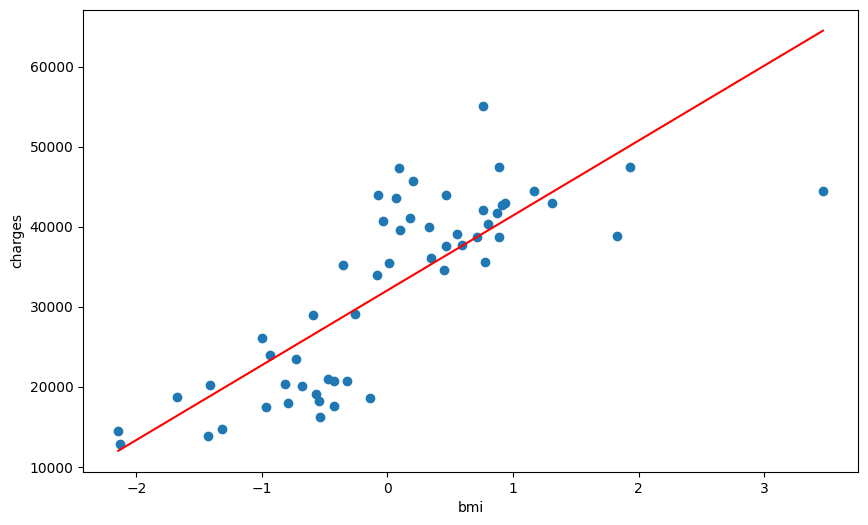

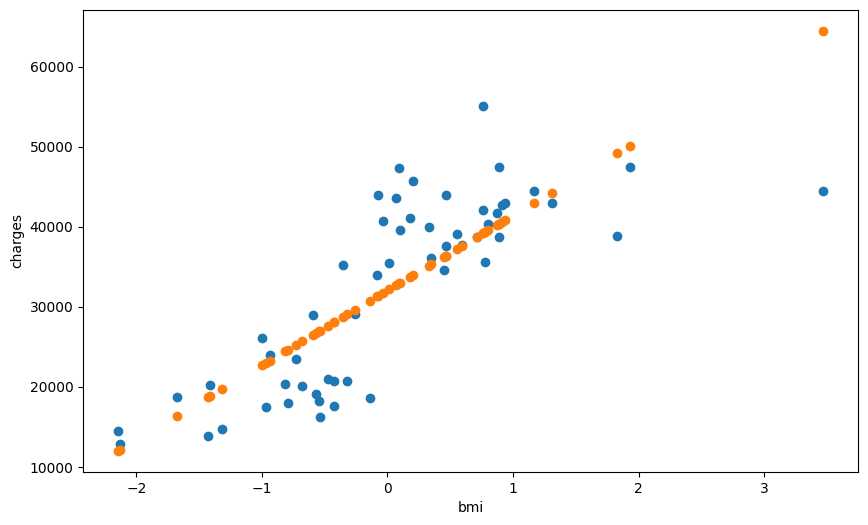

In [ ]:
############# My code here ############

# plot the points
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = X_test, y = y_test)
# plot the line
x_line = np.linspace(np.min(X_test), np.max(X_test), 100)
y_line = intercept + coeff * x_line
ax.plot(x_line, y_line, color='red')
plt.xlabel("bmi")
plt.ylabel("charges")
plt.show()

# addtionally plot the predicted values and the real values as dots
fig, ax = plt.subplots(figsize=(10, 6))
# plot the actual values
ax.scatter(x = X_test, y = y_test)
# plot the predicted values
ax.scatter(x = X_test, y = y_pred)
# show the plot
plt.xlabel("bmi")
plt.ylabel("charges")
plt.show()

#########################################

## Q4. Compute loss. (5 points)

First you must search about the following loss functions and compare them. (By showing their benefits to each other).

- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error
- **R2-score**

Then create a DataFrame similar to the table shown below:

| loss_function | train_set | test_set |
| --- | --- | --- |
| MSE | ... | ... |
| MAE | ... | ... |
| R2-score | ... | ... |

loss_mse: 48843093.93244023, loss_mae: 5379.704514822805, loss_r2: 0.6286654880147234


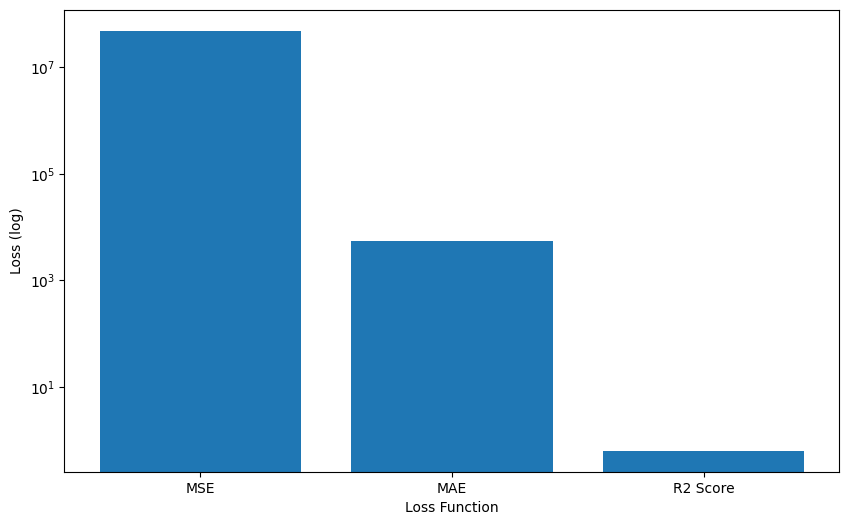

In [ ]:
############# My code here #############

# didn't know we have this part so i redo it here

# first calculate the MSE loss
loss_mse = slr.compute_loss(y_pred, y_test, loss_fn='MSE')
# second calculate the MAE loss
loss_mae = slr.compute_loss(y_pred, y_test, loss_fn='MAE')
# third calculate the R2 score
loss_r2 = slr.compute_loss(y_pred, y_test, loss_fn='R2_Score')

# print the results
print(f'loss_mse: {loss_mse}, loss_mae: {loss_mae}, loss_r2: {loss_r2}')

# show it all in a table
pd.DataFrame({'loss': [loss_mse, loss_mae, loss_r2]}, index=['MSE', 'MAE', 'R2 Score'])

# plot it as well
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=['MSE', 'MAE', 'R2 Score'], height=[loss_mse, loss_mae, loss_r2])
plt.xlabel("Loss Function")
plt.ylabel("Loss (log)")
plt.yscale('log')
plt.show()
#########################################

## 1.2 Underfitting & Overfitting Issues

A model is said to be a good machine learning model if it generalizes any new input data from the problem domain in a proper way. This helps us to make predictions in the future data, that the data model has never seen. Now, suppose we want to check how well our machine learning model learns and generalizes to the new data (Test set). For that, we have overfitting and underfitting, which are majorly responsible for the poor performances of the machine learning algorithms.

- **Underfitting:** A statistical model or a machine learning algorithm is said to have underfitting when it cannot capture the underlying trend of the data. (It’s just like trying to fit undersized pants!) Underfitting destroys the accuracy of our machine learning model. Its occurrence simply means that our model or the algorithm **does not fit the data well enough**. It usually happens when we have fewer data to build an accurate model and also when we try to build a linear model with fewer non-linear data. In such cases, the rules of the machine learning model are too easy and flexible to be applied on such minimal data and therefore the model will probably make a lot of wrong predictions. Underfitting can be avoided by using more data and also reducing the features by feature selection.

    Techniques to reduce underfitting:

    1. Increase model complexity
    2. Increase the number of features, performing feature engineering
    3. Remove noise from the data.
    4. Increase the number of epochs or increase the duration of training to get better results.
    
    
- **Overfitting:** A statistical model is said to be overfitted when we train it with a lot of data (just like fitting ourselves in oversized pants!). When a model gets trained with so much data, it starts learning from the noise and inaccurate data entries in our data set. Then the model does not categorize the data correctly, because of too many details and noise. The causes of overfitting are the non-parametric and non-linear methods because these types of machine learning algorithms have more freedom in building the model based on the dataset and therefore they can really build unrealistic models.

    Techniques to reduce overfitting:

    1. Increase training data.
    2. Reduce model complexity.
    3. Early stopping during the training phase (have an eye over the loss over the training period as soon as loss begins to increase stop training).
    4. Ridge Regularization and Lasso Regularization
    
    In the image below you can see linear regression and polynomial regression models. In the linear model, the model has underfitted and thus it cannot be generalized on all the data point properly (Underfitting). So we can add polynomial features as well to increase the complexity of the model. Therefore, in the middle figure you can see better fittnes of the model on the data points by adding $\{x^2, x^3, x^4\}$ to our hypothesis space.
Although in the right side figure you see less loss than others, but the model is overfitted. It cannot be generalized on the test set (unseen data).
    
<img src="images/underfitting_overfitting.png" width=700 height=700 />


**Note:** The image above is not related to the given `insurance.csv` dataset.

## Q5. Implement `PolynomialRegression` class. (15 points)

Fill the blank lines with using the least possible codes. Note that redundant codes may lead to reduce your score.

**Note**: Do not add any other functions to the class defined below.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics


class PolynomialRegression():
    def __init__(self, degree=3):
        self.degree = degree

    def train(self, X_train, y_train):
        # TODO: Thin function takes X_train: numpy.ndarray and y : numpy.ndarray
        # and fit a linear line to the points with the least loss
        # Use sklearn.linear_model.LinearRegression for this purpose
        # At last this function must set the intercept and coefficient of the predicted line

        intercept = None
        coeff = None
        ############# My code here ############

        # polynomial features
        x_train_pol = self.generate_polynomial_features(X_train)

        # polynomial regression
        model = LinearRegression()

        # fit the model
        model.fit(x_train_pol, y_train)

        # save the model for later use
        self.train_model = model

        # get the intercept and coefficient
        intercept = model.intercept_
        coeff = model.coef_[0]

        #########################################

        return coeff, intercept

    def compute_loss(self, y_pred, y_true, loss_fn = 'MSE'):
        # TODO: Implement this function that takes y_pred and y_true
        # as a 1-dimensional numpy array (n_samples,) and returns
        # the loss using sklearn.metrics functions

        possible_loss_functions = ['MSE', 'MAE', 'R2_Score']

        loss = None
        if loss_fn == 'MSE':
            ############# My code here ############
            # this is the mean squared error
            loss = metrics.mean_squared_error(y_true, y_pred)
            #########################################
        elif loss_fn == 'MAE':
            ############# My code here ############
            # this is the mean absolute error
            loss = metrics.mean_absolute_error(y_true, y_pred)
            #########################################
        elif loss_fn == 'R2_Score':
            ############# My code here ############
            # this is the r2 score
            loss = metrics.r2_score(y_true, y_pred)
            #########################################
        else:
            error_str = 'Loss function is either unknown or not implemented.'
            raise NotImplementedError(error_str)

        return loss

    def normalize(self, X, normalization='Standardization'):
        # TODO: Implement this function that takes X : numpy.ndarray
        # as the input feature array and normalize it
        # You can use sklearn.preprocessing normalizations functions too.
        # NOTE: For test set, you must use the mean and std of train set (standardization)
        # of the train set. (since test set has not seen so far)
        possible_normalization = ['Standardization', 'MinMaxScaling']

        nomalaized_feat = None
        if normalization == 'Standardization':
            ############# My code here ############
            # this is the standardization
            nomalaized_feat = (X - np.mean(X)) / np.std(X)
            #########################################
        elif normalization == 'MinMaxScaling':
            ############# My code here ############
            # this is the min max scaling
            nomalaized_feat = (X - np.min(X)) / (np.max(X) - np.min(X))
            #########################################
        else:
            error_str = 'Normalization type is either unknown or not implemented.'
            raise NotImplementedError(error_str)

        return nomalaized_feat

    def generate_polynomial_features(self, X): # here why do we need X?
        # TODO: Implement this function that takes degree: int and X: numpy.ndarray
        # to return polnomial features of those input features.
        # Use sklearn.preprocessing.PolynomialFeatures. Read its documentation for more info.
        X_pol = None

        ############# My code here ############
        # create the polynomial features object
        X_pol = PolynomialFeatures(degree=self.degree, include_bias=False) # we want to use polynomial features and linear regression
        # fit the polynomial features
        X_pol = X_pol.fit_transform(X.reshape(-1, 1))
        #########################################

        return X_pol


    def prepare_dataset(self, X, y, test_size=0.2, random_state=42):
        # TODO: Implement this function that takes X : numpy.ndarray and y : numpy.ndarray
        # and use sklearn.model_selection.train_test_split to split your data into test and train sets
        X_train, y_train, X_test, y_test = None, None, None, None
        ############# My code here ############
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
        #########################################
        return X_train, y_train, X_test, y_test

    def predict(self, X):
        """
        Predicts the y values for each x in X.

        Args:
            X (numpy.ndarray): The input array.

        Returns:
            y_pred (numpy.ndarray): The predictions.
        """
        # polynomial features
        x_pol = self.generate_polynomial_features(X)

        # predict the y values
        y_pred = self.train_model.predict(x_pol)

        return y_pred

## Q6. Find the best polynomial degree. (10 points)

The best polynomial degree is the one with the least loss for test set data points. So use the implemented `PolynomialRegression`above multiple times to find the best one.

degree: 1 ----------------------------------------------------------------------------------------------------
coeff: 9354.427299939905, intercept: 32045.08414281797
loss_mse: 48843093.93244023, loss_mae: 5379.704514822805, loss_r2: 0.6286654880147234
----------------------------------------------------------------------------------------------------


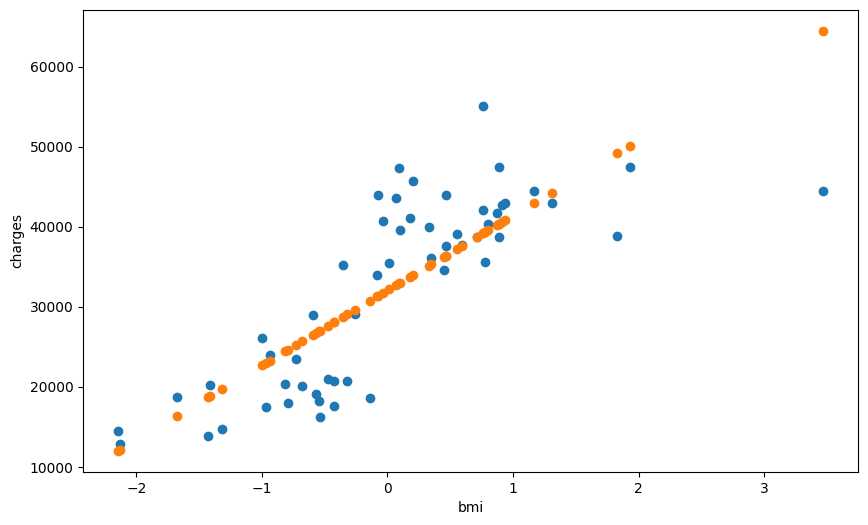

degree: 2 ----------------------------------------------------------------------------------------------------
coeff: 9514.122648850122, intercept: 32651.526102229815
loss_mse: 43886806.69016466, loss_mae: 5233.675203457193, loss_r2: 0.6663461580172205
----------------------------------------------------------------------------------------------------


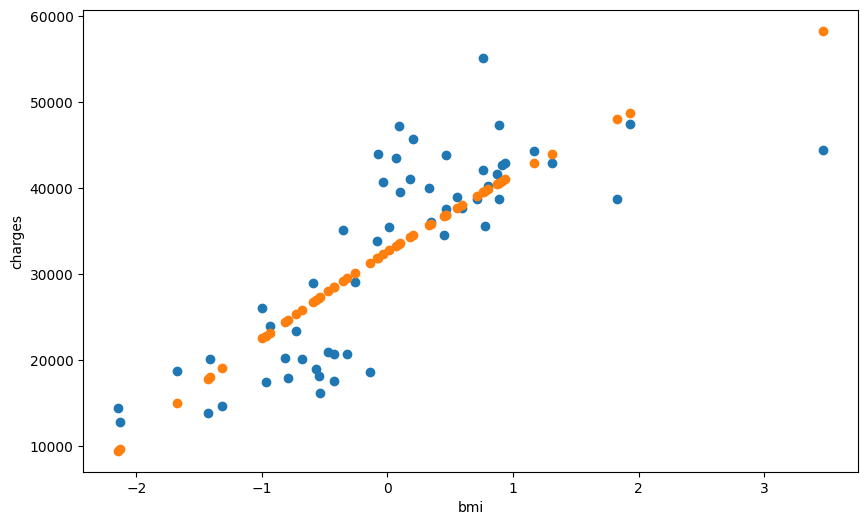

degree: 3 ----------------------------------------------------------------------------------------------------
coeff: 12950.908593649074, intercept: 32024.862099136342
loss_mse: 45721014.21819359, loss_mae: 5157.021133536846, loss_r2: 0.6524014116372626
----------------------------------------------------------------------------------------------------


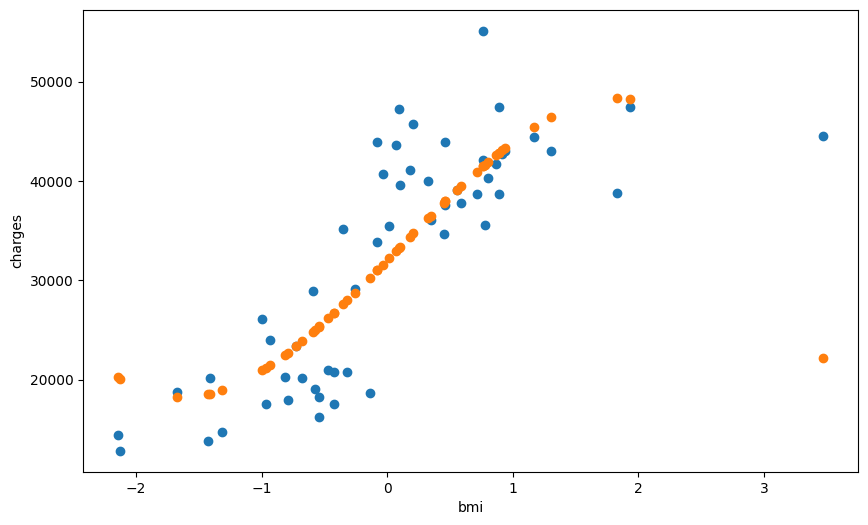

degree: 4 ----------------------------------------------------------------------------------------------------
coeff: 14273.041225547458, intercept: 33269.46536455887
loss_mse: 51012032.28116656, loss_mae: 5268.723235403953, loss_r2: 0.6121759170558387
----------------------------------------------------------------------------------------------------


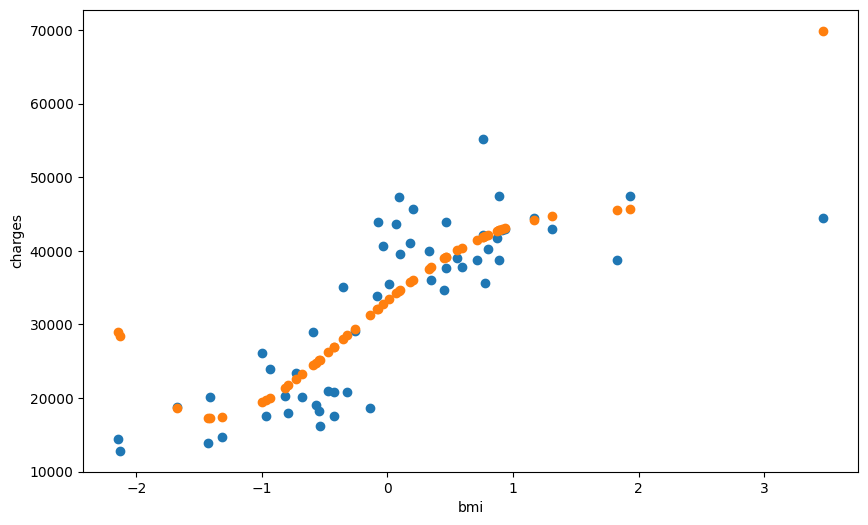

degree: 5 ----------------------------------------------------------------------------------------------------
coeff: 16828.30069391732, intercept: 32655.649168102802
loss_mse: 254342607.7226972, loss_mae: 6694.881447023643, loss_r2: -0.9336651410004528
----------------------------------------------------------------------------------------------------


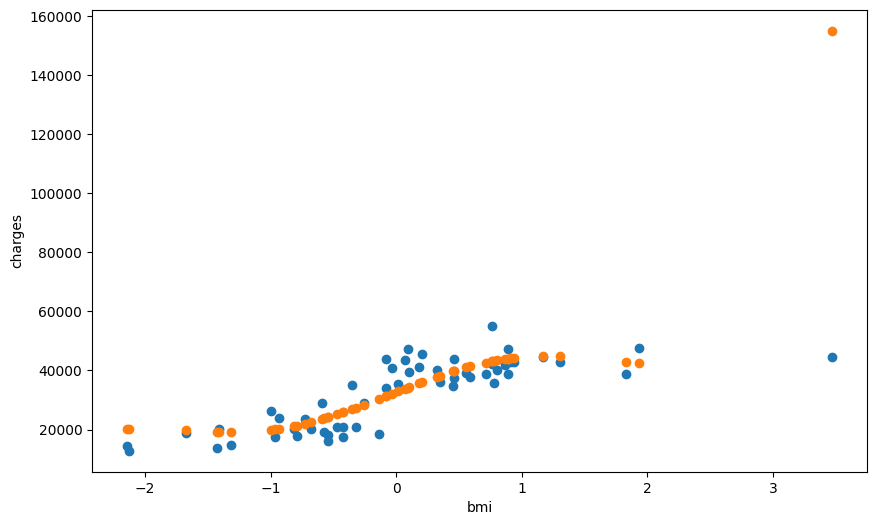

degree: 6 ----------------------------------------------------------------------------------------------------
coeff: 17482.59895279889, intercept: 32916.748749611674
loss_mse: 91171569.76272045, loss_mae: 5556.560736959089, loss_r2: 0.3068590124204694
----------------------------------------------------------------------------------------------------


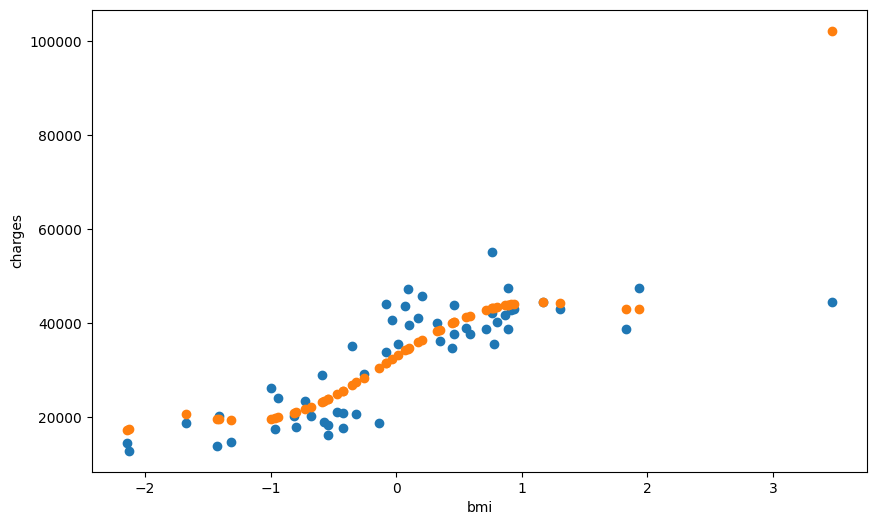

degree: 7 ----------------------------------------------------------------------------------------------------
coeff: 18797.18634104114, intercept: 32548.250281080997
loss_mse: 425099757.94150114, loss_mae: 7437.700909610293, loss_r2: -2.231863472420696
----------------------------------------------------------------------------------------------------


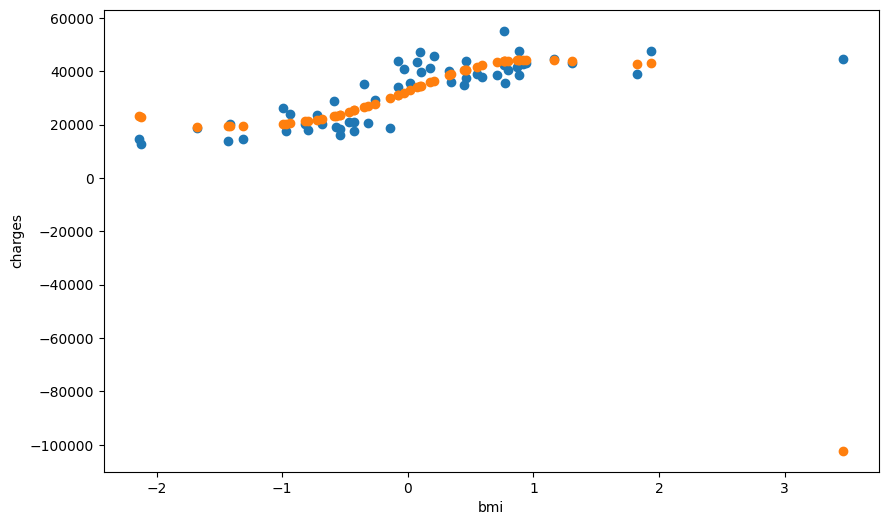

degree: 8 ----------------------------------------------------------------------------------------------------
coeff: 23833.015517125503, intercept: 33513.03146331818
loss_mse: 18311101239.10659, loss_mae: 23361.234426396815, loss_r2: -138.2119805502446
----------------------------------------------------------------------------------------------------


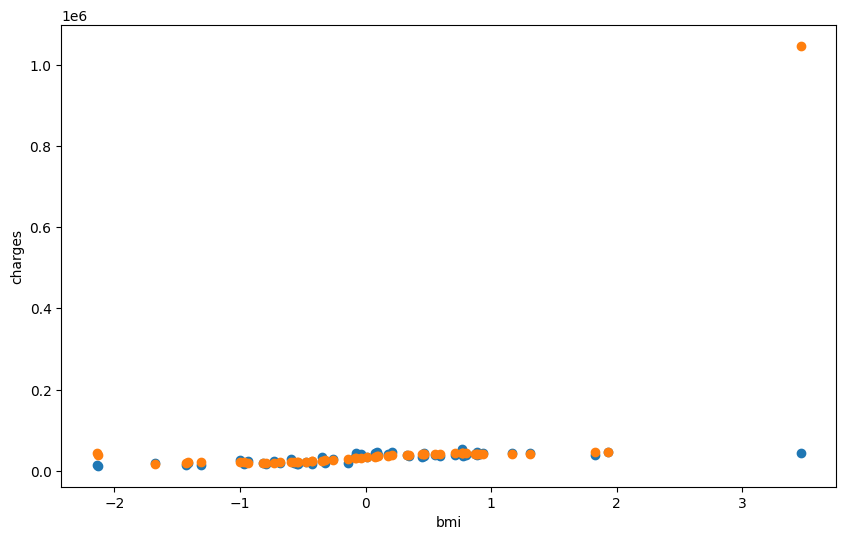

degree: 9 ----------------------------------------------------------------------------------------------------
coeff: 23636.989131766724, intercept: 33591.94390586477
loss_mse: 12792828116.84607, loss_mae: 20393.279188471322, loss_r2: -96.25875662691104
----------------------------------------------------------------------------------------------------


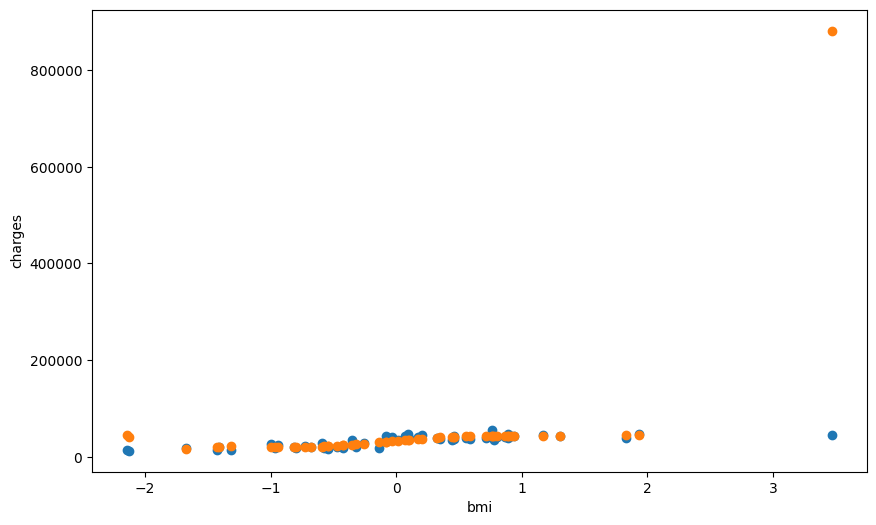

degree: 10 ----------------------------------------------------------------------------------------------------
coeff: 28009.117639395976, intercept: 33998.50286826919
loss_mse: 244084037568.07916, loss_mae: 70847.0754743992, loss_r2: -1854.6733342713187
----------------------------------------------------------------------------------------------------


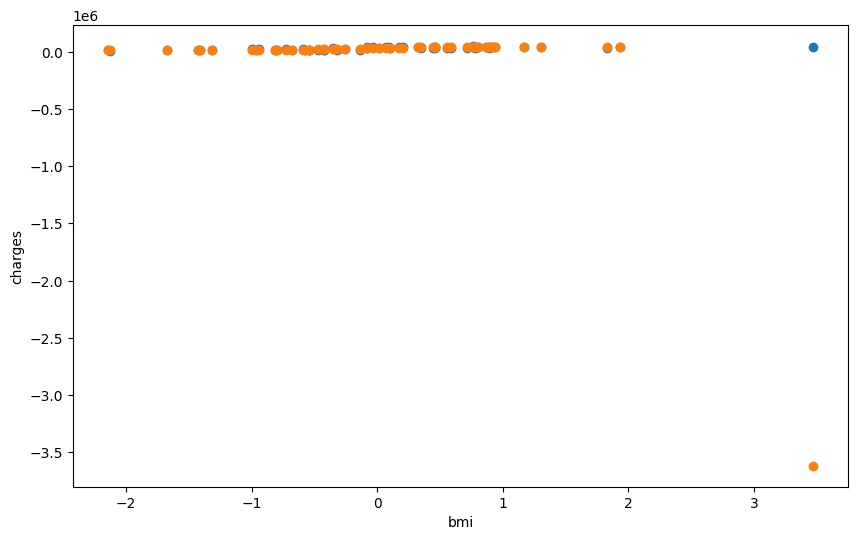

degree: 11 ----------------------------------------------------------------------------------------------------
coeff: 28343.140500582063, intercept: 33783.957663262685
loss_mse: 677803462931.9955, loss_mae: 115573.39618681905, loss_r2: -5152.068691306148
----------------------------------------------------------------------------------------------------


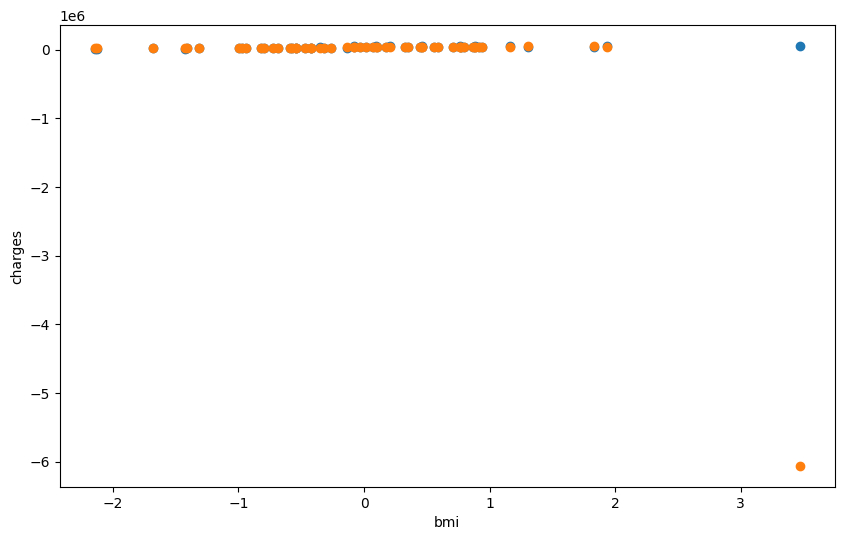

degree: 12 ----------------------------------------------------------------------------------------------------
coeff: 30795.184859555597, intercept: 33842.30897187513
loss_mse: 286420399921.80963, loss_mae: 77352.26042316388, loss_r2: -2176.5397679497332
----------------------------------------------------------------------------------------------------


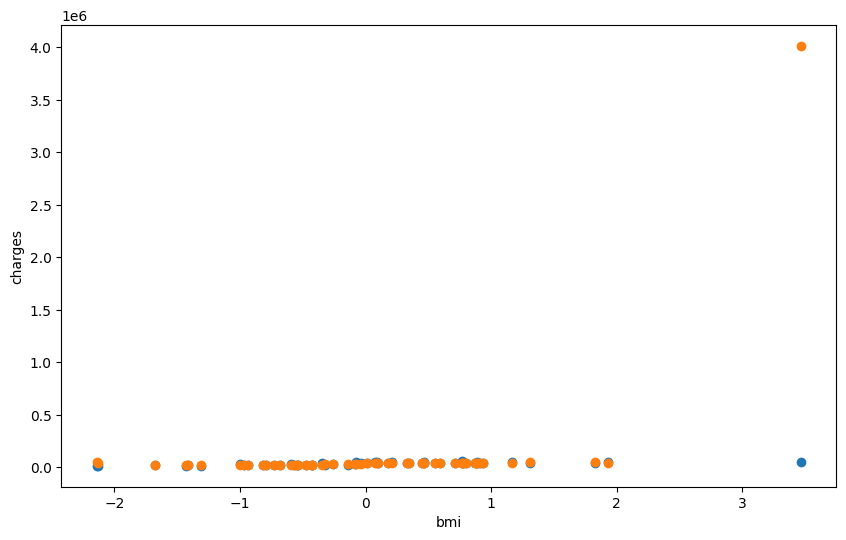

degree: 13 ----------------------------------------------------------------------------------------------------
coeff: 30151.660140180917, intercept: 34777.581454871935
loss_mse: 39503032651540.73, loss_mae: 854040.0689578154, loss_r2: -300324.7609333319
----------------------------------------------------------------------------------------------------


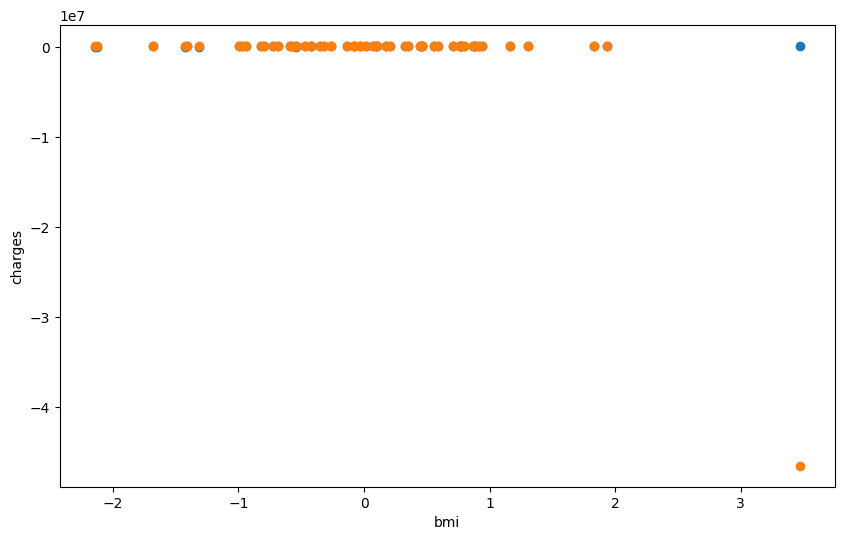

degree: 14 ----------------------------------------------------------------------------------------------------
coeff: 33298.33269363906, intercept: 34703.3645866578
loss_mse: 170670292068413.5, loss_mae: 1767128.1111291163, loss_r2: -1297536.9836353182
----------------------------------------------------------------------------------------------------


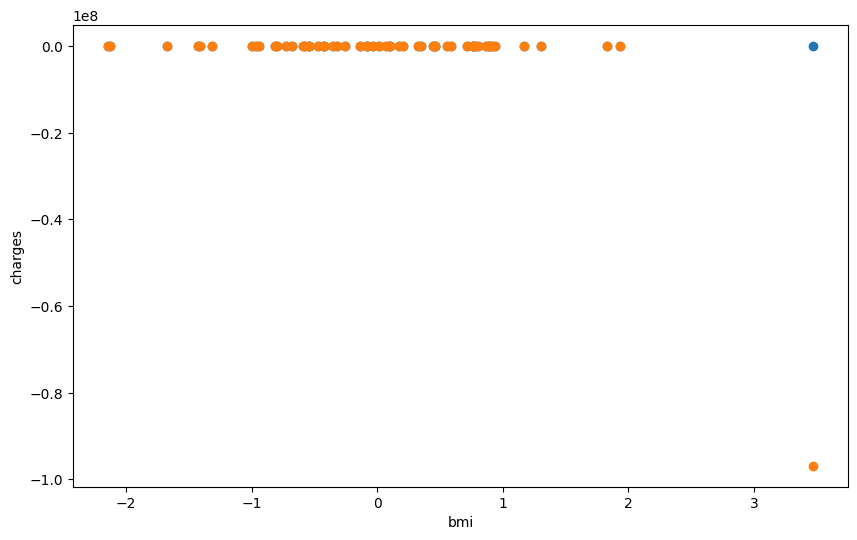

degree: 15 ----------------------------------------------------------------------------------------------------
coeff: 33073.6710576765, intercept: 34582.84818147014
loss_mse: 310469006182070.5, loss_mae: 2381904.953229865, loss_r2: -2360370.7048850167
----------------------------------------------------------------------------------------------------


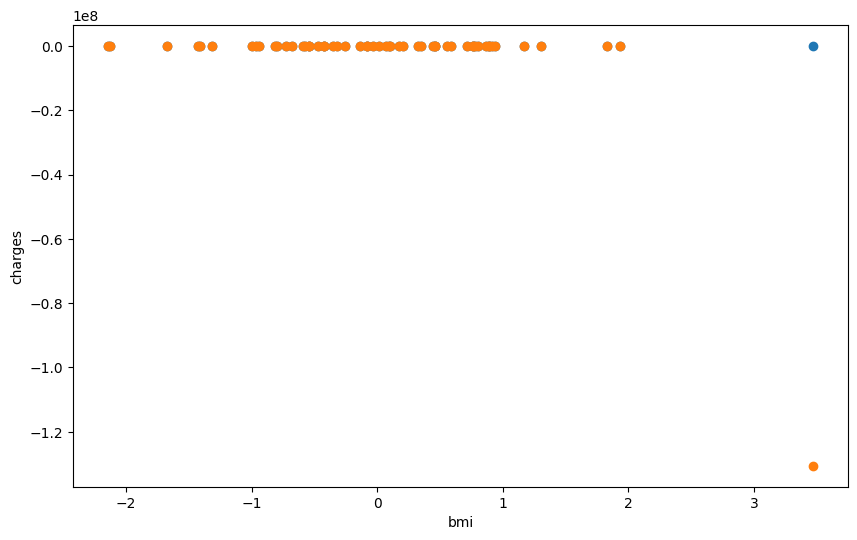

degree: 16 ----------------------------------------------------------------------------------------------------
coeff: 34629.91827316219, intercept: 34484.029510952314
loss_mse: 18437316399538.934, loss_mae: 585791.2362338189, loss_r2: -140170.54394459294
----------------------------------------------------------------------------------------------------


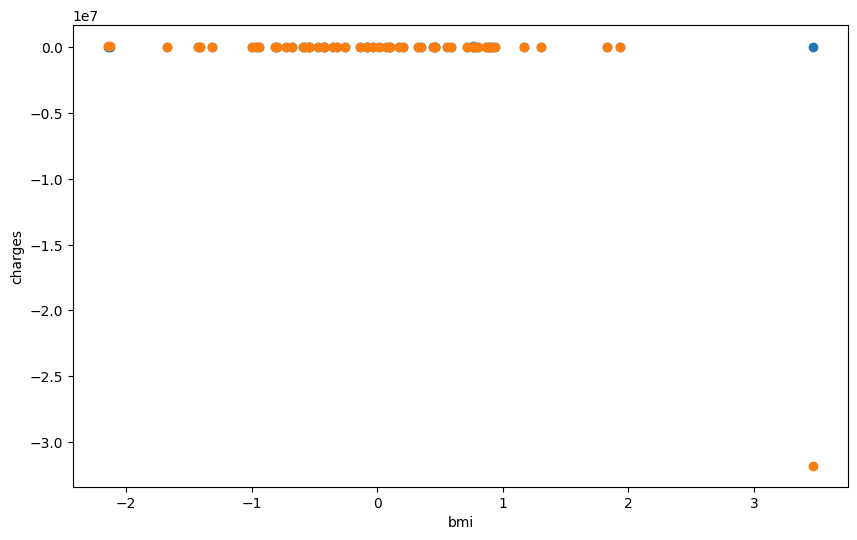

degree: 17 ----------------------------------------------------------------------------------------------------
coeff: 38267.63290349733, intercept: 35152.914836562195
loss_mse: 1.6501958462053532e+16, loss_mae: 17332672.307649713, loss_r2: -125457790.44916275
----------------------------------------------------------------------------------------------------


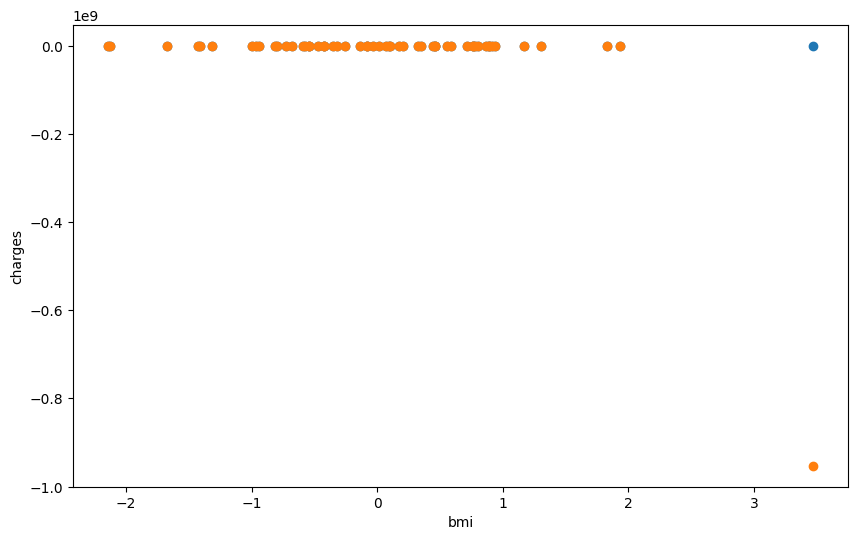

degree: 18 ----------------------------------------------------------------------------------------------------
coeff: 40084.46948847843, intercept: 35008.8240220509
loss_mse: 4.438215941270436e+16, loss_mae: 28416492.969985962, loss_r2: -337419809.6525628
----------------------------------------------------------------------------------------------------


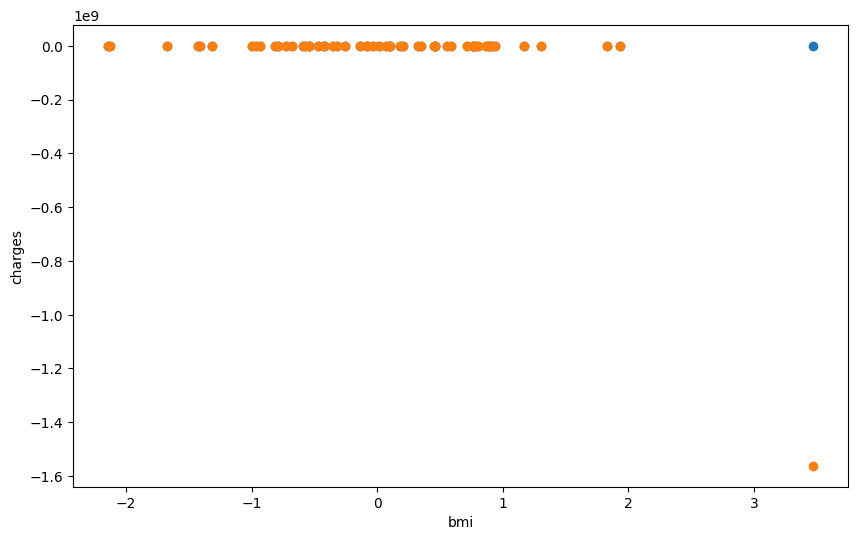

degree: 19 ----------------------------------------------------------------------------------------------------
coeff: 44363.59154359221, intercept: 35372.806823567444
loss_mse: 7.200620273752133e+16, loss_mae: 36187377.86588117, loss_r2: -547434364.8580455
----------------------------------------------------------------------------------------------------


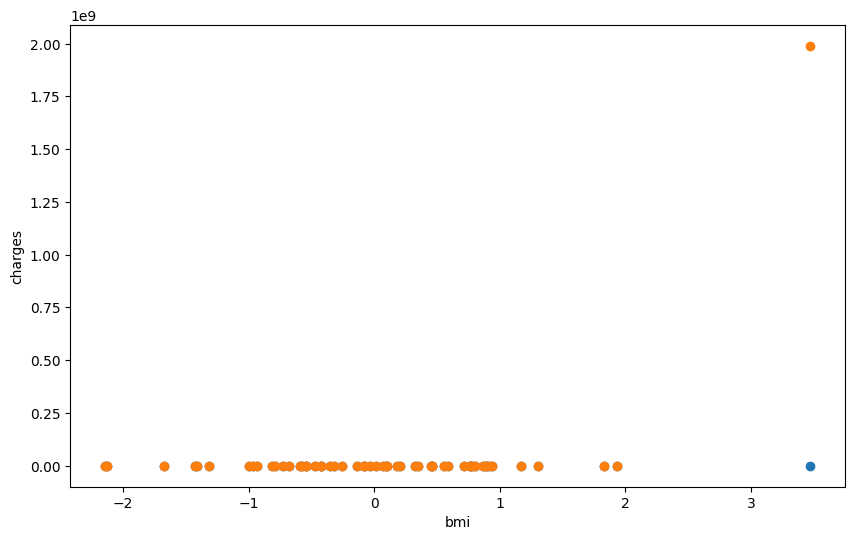


 best_degree: 2, least_loss: 43886806.69016466


In [ ]:
best_degree = 1
least_loss = 0.0

for degree in range(1,20):
    pr = PolynomialRegression(degree=degree)
    ############# My code here ##############

    # first normalize the data with standardization
    # X = pr.normalize(X) # already normalized

    # second prepare the dataset
    # X_train, y_train, X_test, y_test = pr.prepare_dataset(X, target) # already prepared

    # third train the model
    coeff, intercept = pr.train(X_train, y_train)

    # fourth predict the test set
    y_pred = pr.predict(X_test)

    # fifth compute the loss
    loss_mse = pr.compute_loss(y_pred, y_test, loss_fn='MSE')
    loss_mae = pr.compute_loss(y_pred, y_test, loss_fn='MAE')
    loss_r2 = pr.compute_loss(y_pred, y_test, loss_fn='R2_Score')

    print(f'degree: {degree}', 100*'-')

    # sixth print the results
    print(f'coeff: {coeff}, intercept: {intercept}')

    # print the loss
    print(f'loss_mse: {loss_mse}, loss_mae: {loss_mae}, loss_r2: {loss_r2}')

    print(100*'-')

    if least_loss == 0.0 or least_loss > loss_mse:
        least_loss = loss_mse
        best_degree = degree

    # plot the points
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x = X_test, y = y_test)
    # plot the predicted values
    ax.scatter(x = X_test, y = y_pred)
    # show the plot
    plt.xlabel("bmi")
    plt.ylabel("charges")
    plt.show()

    #########################################

print(f'\n best_degree: {best_degree}, least_loss: {least_loss}')

## Q7. Plot some experimental results (5 points)

Use `plt.subplot` to plot the predicted polynomial model **for degrees, 1, 4 and 20**.

So note that you must present 1 figure with 3 plots.

Also consider these:
- Set the title of each plot to ***Polynomial Fit degree i***
- Print loss of each model on both train and test set.

degree: 1 ----------------------------------------------------------------------------------------------------
loss_mse_train: 45788820.509763926, loss_mae_train: 5146.868721151195, loss_r2_train: 0.6557427276584304
loss_mse_test: 48843093.93244023, loss_mae_test: 5379.704514822805, loss_r2_test: 0.6286654880147234
degree: 4 ----------------------------------------------------------------------------------------------------
loss_mse_train: 37374998.9013345, loss_mae_train: 4622.567269617417, loss_r2_train: 0.7190009475610117
loss_mse_test: 51012032.28116656, loss_mae_test: 5268.723235403953, loss_r2_test: 0.6121759170558387
degree: 20 ----------------------------------------------------------------------------------------------------
loss_mse_train: 27535697.635993443, loss_mae_train: 3955.856500947759, loss_r2_train: 0.7929764502632701
loss_mse_test: 1.7896490980085104e+16, loss_mae_test: 18044125.140838463, loss_r2_test: -136059863.54361346


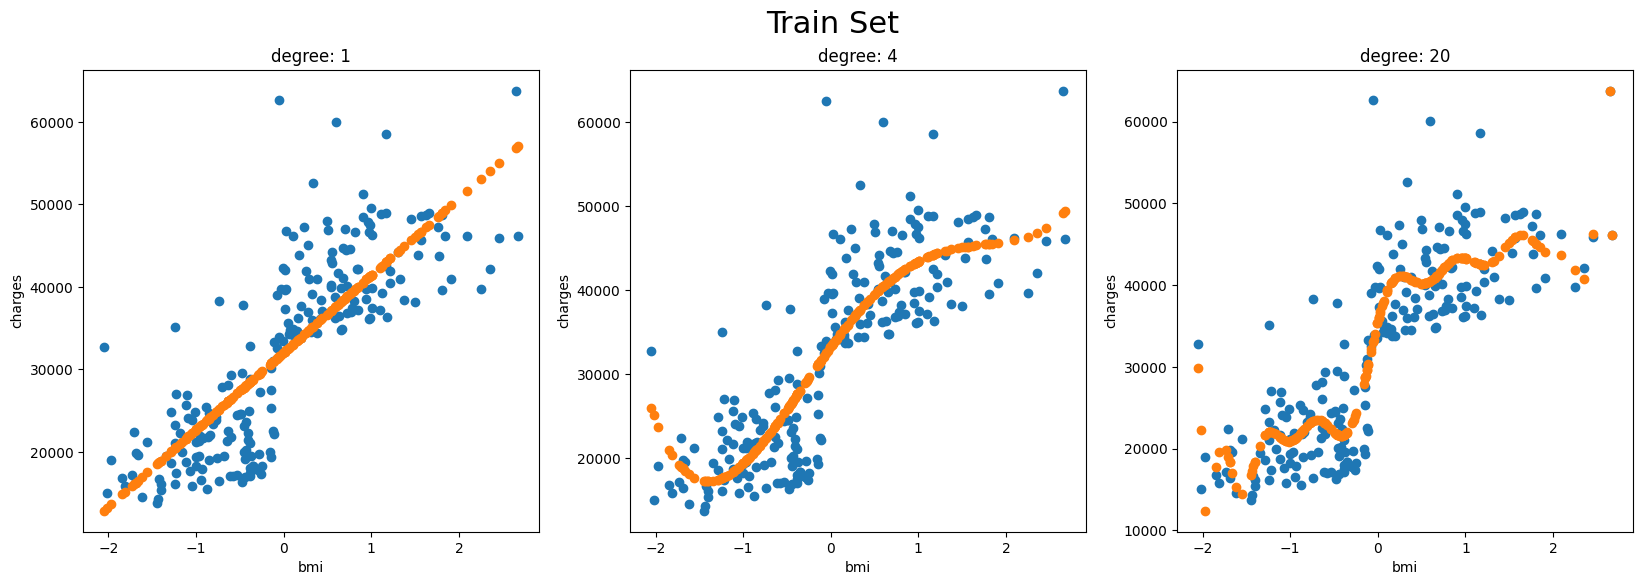

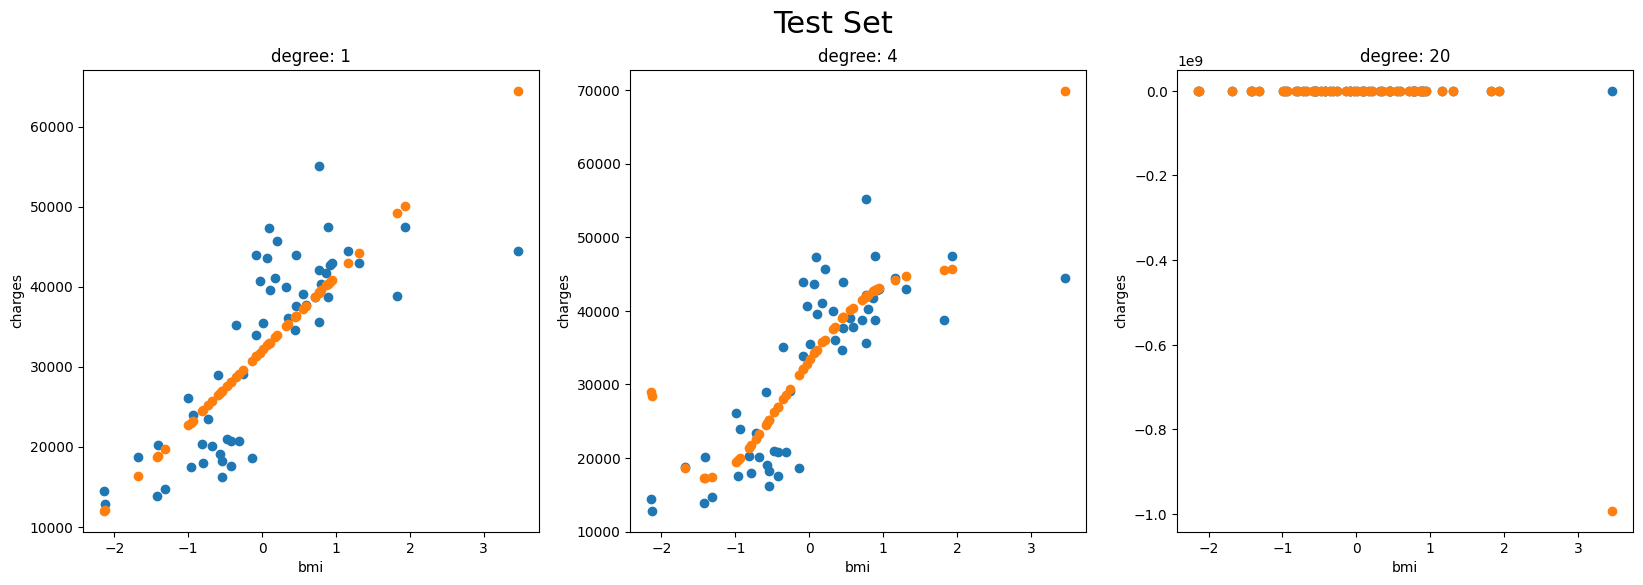

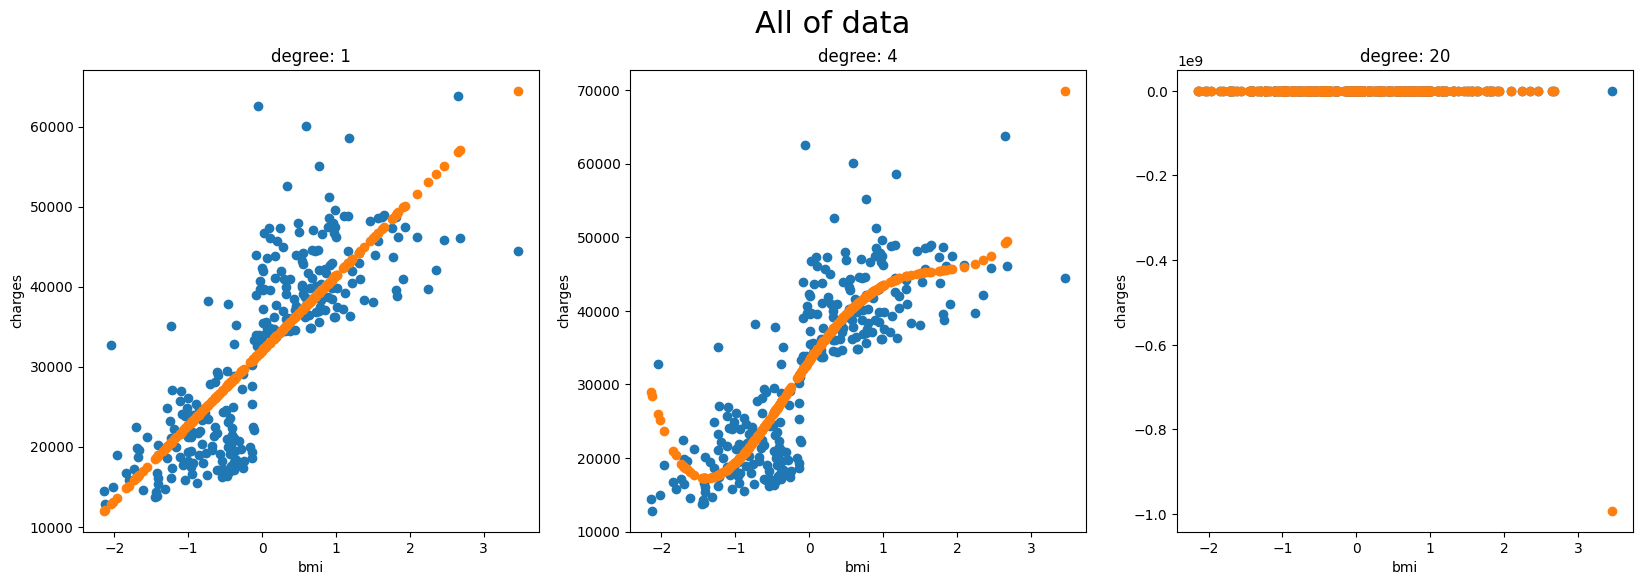

In [ ]:
############# My code here ############

results = {}

for d in [1,4,20]:
  # the polynomial regression with degree d
  pr = PolynomialRegression(degree=d)
  pr.train(X_train, y_train)
  y_pred_train = pr.predict(X_train)
  y_pred_test = pr.predict(X_test)
  y_pred_all = pr.predict(X)

  # add the results to the dictionary
  results[d] = {
    'train': y_pred_train,
    'test': y_pred_test,
    'all': y_pred_all,
  }

  # calculate the loss for train and test
  loss_mse_train = pr.compute_loss(y_pred_train, y_train, loss_fn='MSE')
  loss_mae_train = pr.compute_loss(y_pred_train, y_train, loss_fn='MAE')
  loss_r2_train = pr.compute_loss(y_pred_train, y_train, loss_fn='R2_Score')
  loss_mse_test = pr.compute_loss(y_pred_test, y_test, loss_fn='MSE')
  loss_mae_test = pr.compute_loss(y_pred_test, y_test, loss_fn='MAE')
  loss_r2_test = pr.compute_loss(y_pred_test, y_test, loss_fn='R2_Score')

  # print the results
  print(f'degree: {d}', 100*'-')
  print(f'loss_mse_train: {loss_mse_train}, loss_mae_train: {loss_mae_train}, loss_r2_train: {loss_r2_train}')
  print(f'loss_mse_test: {loss_mse_test}, loss_mae_test: {loss_mae_test}, loss_r2_test: {loss_r2_test}')

# create the figure that includes all the plots 1, 4, 20 title: train
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('Train Set', fontsize=22)
# plot the points for train set
for i, d in enumerate([1,4,20]):
  # plot the actual values
  ax[i].scatter(x = X_train, y = y_train)
  # plot the predicted values
  ax[i].scatter(x = X_train, y = results[d]['train'])
  # set the title
  ax[i].set_title(f'degree: {d}')
  # set the labels
  ax[i].set_xlabel("bmi")
  ax[i].set_ylabel("charges")
plt.show()

# create the figure that includes all the plots 1, 4, 20 title: test
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('Test Set', fontsize=22)
# plot the points for test set
for i, d in enumerate([1,4,20]):
  # plot the actual values
  ax[i].scatter(x = X_test, y = y_test)
  # plot the predicted values
  ax[i].scatter(x = X_test, y = results[d]['test'])
  # set the title
  ax[i].set_title(f'degree: {d}')
  # set the labels
  ax[i].set_xlabel("bmi")
  ax[i].set_ylabel("charges")
plt.show()


# create the figure that includes all the plots 1, 4, 20 title: all
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('All of data', fontsize=22)
# plot the points for all set
for i, d in enumerate([1,4,20]):
  # plot the actual values
  ax[i].scatter(x = X, y = target)
  # plot the predicted values
  ax[i].scatter(x = X, y = results[d]['all'])
  # set the title
  ax[i].set_title(f'degree: {d}')
  # set the labels
  ax[i].set_xlabel("bmi")
  ax[i].set_ylabel("charges")
plt.show()

#########################################

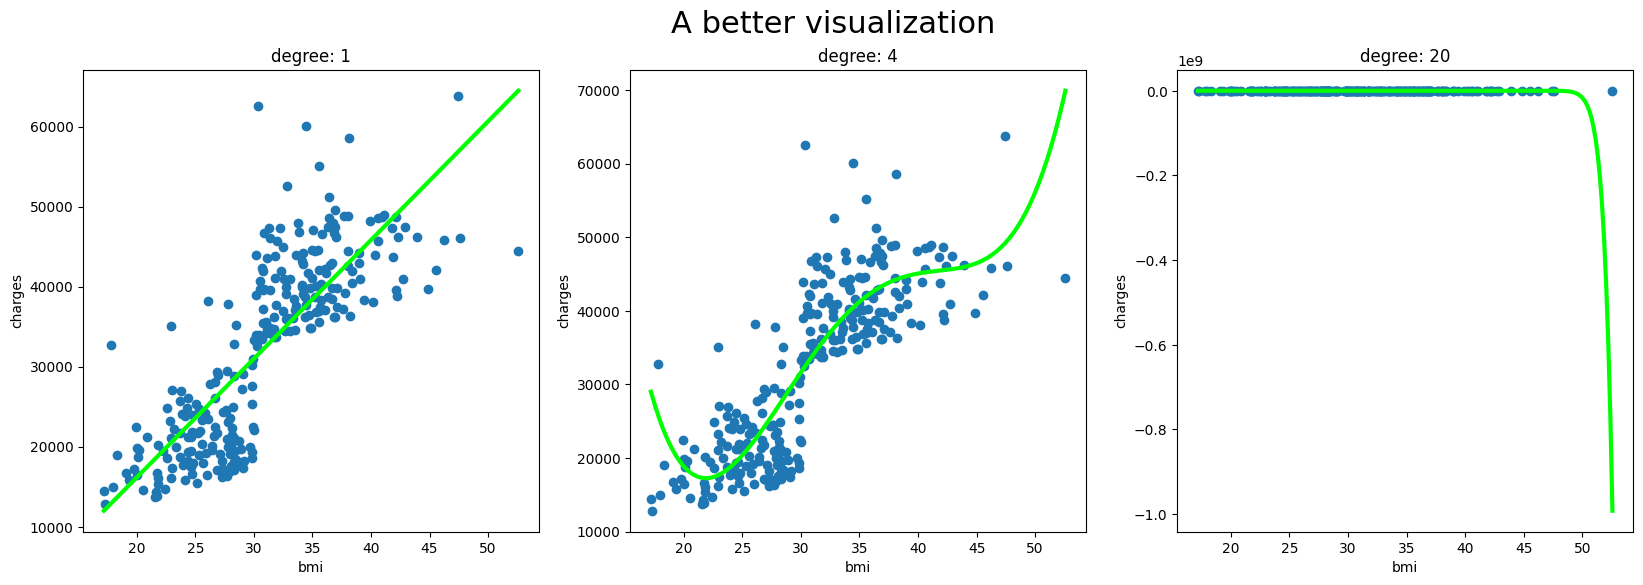

In [ ]:
############# This plot may be useful ############

results = {}

for d in [1,4,20]:
  # the polynomial regression with degree d
  pr = PolynomialRegression(degree=d)
  pr.train(X_train, y_train)

  # create values in range of X min and max
  X_range = np.linspace(np.min(X), np.max(X), 200)

  # predict the values
  y_pred = pr.predict(X_range)

  # new x_range for plotting
  x_range = np.linspace(np.min(X_not_normalized), np.max(X_not_normalized), 200)

  # add the results to the dictionary
  results[d] = {
    'predicted': y_pred,
  }

# create the figure that includes all the plots 1, 4, 20 title: train
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('A better visualization', fontsize=22)
# plot the points for train set
for i, d in enumerate([1,4,20]):
  # plot the actual values
  ax[i].scatter(x = X_not_normalized, y = target)
  # plot the predicted values
  ax[i].plot(x_range, results[d]['predicted'], color='lime', linewidth=3)
  # set the title
  ax[i].set_title(f'degree: {d}')
  # set the labels
  ax[i].set_xlabel("bmi")
  ax[i].set_ylabel("charges")
plt.show()

#########################################

# Submission

Please read the notes here carefully:

    The more beautiful and insightfull your plots and diagrams are, the more points you get. So please take your time and concentration to prepare a good report with nice diagrams.

    The file you upload must be named as [Student ID]-[Your name].zip and it must contain only 1 file:

    Linear_and_Logistic_Regression.ipynb

    Important Note: The outputs of the code blocks must be remained in your notebook, otherwise, you definitly lose all the points of that

In case you have any questions, contact @Taraa_brn or @Haanieh97.